In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.gridspec as gridspec

In [2]:
df = pd.read_csv("../data/ouput/stats_total.csv").drop(columns={"Unnamed: 0"})

In [3]:
df_20 = df[(df["months"] >= "2020-01") & (df["months"] <= "2025-12")]

In [4]:
df_20 = df_20.rename(columns={"months":"Months"})

In [5]:
df[(df["months"] >= "2022-01") & (df["months"] <= "2025-12")].sort_values(by ="Edits")

,months,Contributors,New Contributors,Edits,Changesets,Accumulated Contributors,Accumulated Edits,Accumulated Changesets
231,2024-07,47120,11765,88282660,1282810,2193516.0,1.633887e+10,154981159.0
232,2024-08,48283,10790,88569331,1364886,2204306.0,1.642744e+10,156346045.0
233,2024-09,47780,11575,92111182,1283037,2215881.0,1.651955e+10,157629082.0
219,2023-07,48036,12144,92629782,1298679,2034812.0,1.496361e+10,139575112.0
207,2022-07,46577,12412,93316695,1257299,1879241.0,1.369658e+10,124617269.0
212,2022-12,41556,10912,96760328,1155518,1942650.0,1.421471e+10,131032962.0
218,2023-06,47769,12692,96782598,1168217,2022668.0,1.487098e+10,138276433.0
247,2025-11,52241,15527,98291045,1295083,2393376.0,1.801111e+10,175666313.0
208,2022-08,47821,12029,98855540,1311540,1891270.0,1.379544e+10,125928809.0
230,2024-06,48802,13088,99879796,1289767,2181751.0,1.625059e+10,153698349.0


In [6]:
from matplotlib.ticker import FuncFormatter
def millions(x, pos):
    'The two args are the value and tick position'
    return '%1.f million' % (x * 1e-6)


formatter = FuncFormatter(millions)
plain_formatter = FuncFormatter(lambda x, _: f"{int(x):,}")

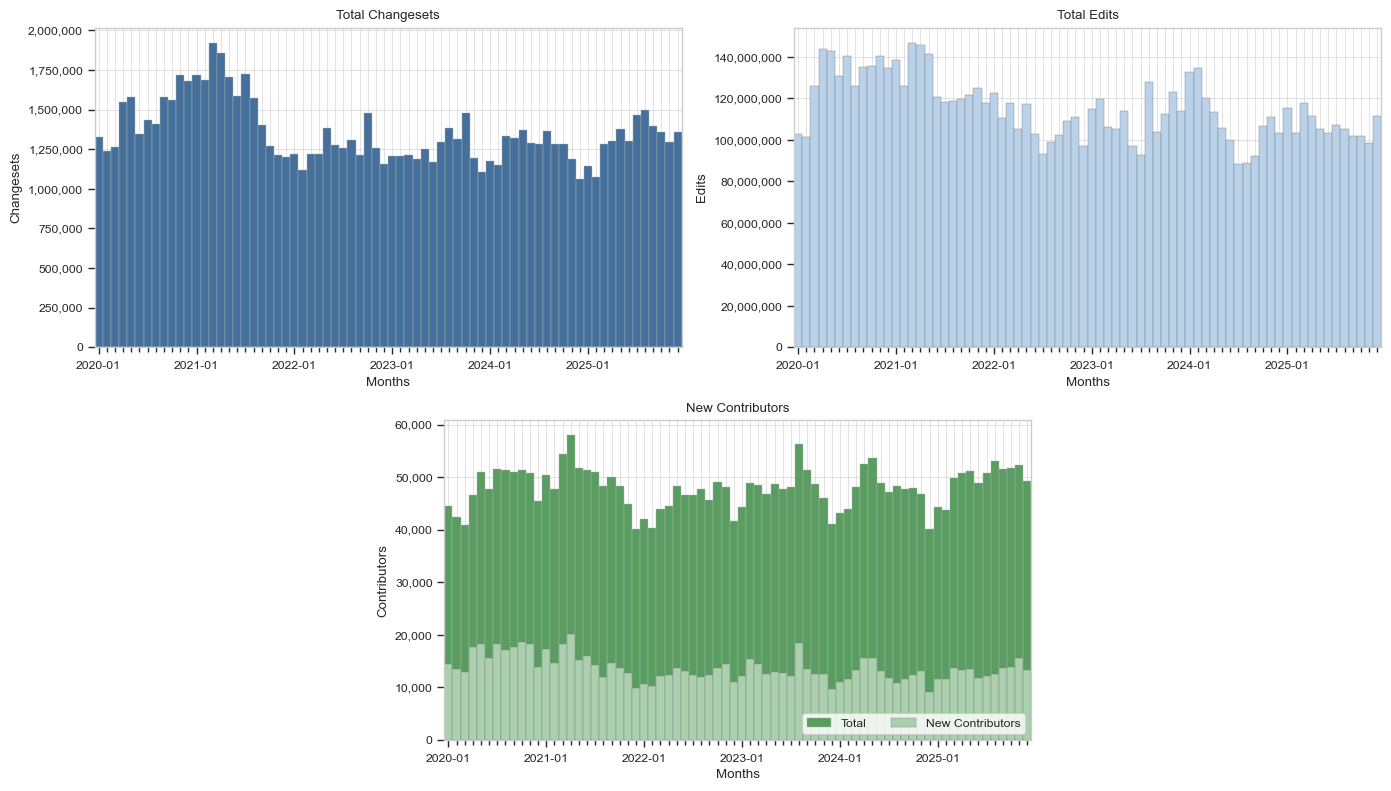

In [17]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper")

f = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 4, figure=f)

ax0 = f.add_subplot(gs[0, 0:2])
ax2 = f.add_subplot(gs[0, 2:4])
ax3 = f.add_subplot(gs[1, 1:3])   # centered under ax0/ax2

#f.suptitle("OpenStreetMap Contributions 2020–2026", fontsize=13, fontweight="bold", y=1.01)

def show_every_nth_ticklabel(ax, n=12, long_len=20, short_len=3.5, pad=5):
    for i, tick in enumerate(ax.xaxis.get_major_ticks()):
        show = (i % n == 0)
        tick.label1.set_visible(show)
        tick.tick1line.set_visible(True)
        tick.tick1line.set_markersize(long_len if show else short_len)
        if show:
            tick.set_pad(pad)

        
# Plot the total Changesets
ax0.set_title("Total Changesets")
sns.barplot(x="Months", y="Changesets", data=df_20, width=1,edgecolor="0.7", linewidth=0.3,
            legend=False, color="#3670AB", ax=ax0)
ax0.yaxis.set_major_formatter(plain_formatter)
ax0.grid( lw='0.4')

#Plot the total edits
ax2.set_title("Total Edits")
sns.barplot(x="Months", y="Edits", data=df_20, width=1,edgecolor="grey", linewidth=0.3,
            legend=False, color="#B1D2F1", ax=ax2)
ax2.yaxis.set_major_formatter(plain_formatter)
ax2.grid(lw='0.4')

# Plot the New Contributors
ax3.set_title("New Contributors")
sns.barplot(x="Months", y="Contributors", data=df_20, ax=ax3, width=1,edgecolor="0.7", linewidth=0.3,
            label="Total", color="#4DAA57")

# Plot the crashes where alcohol was involved
sns.barplot(x="Months", y="New Contributors", data=df_20,ax=ax3,width=1, edgecolor="grey", linewidth=0.3,
            label="New Contributors", color="#a4d6a9")

# Add a legend and informative axis label
ax3.legend(ncol=2, loc="lower right", frameon=True, facecolor="w")
ax3.yaxis.set_major_formatter(plain_formatter)
ax3.grid(lw='0.4')

show_every_nth_ticklabel(ax0)
show_every_nth_ticklabel(ax2)
show_every_nth_ticklabel(ax3)


#ax0.set_axisbelow(False)
#ax2.set_axisbelow(False)
#ax3.set_axisbelow(False)
#sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

f.savefig("../results/Edits_CS_NewContrib_20_25_v2.png", bbox_inches="tight", dpi=300)

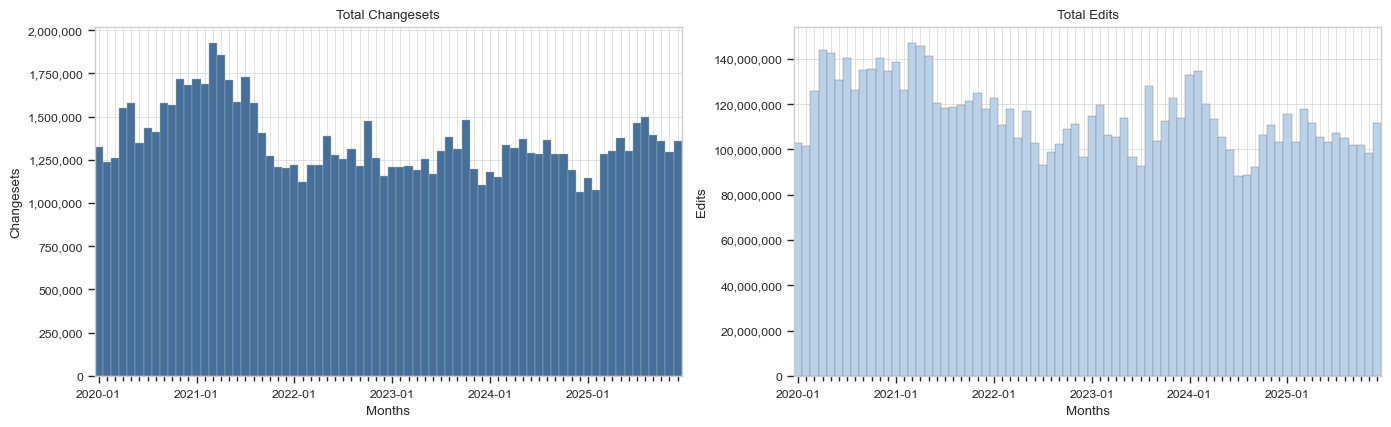

In [18]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper")

f = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 4, figure=f)

ax0 = f.add_subplot(gs[0, 0:2])
ax2 = f.add_subplot(gs[0, 2:4])
#ax3 = f.add_subplot(gs[1, 1:3])   # centered under ax0/ax2

#f.suptitle("OpenStreetMap Contributions 2020–2026", fontsize=13, fontweight="bold", y=1.01)

def show_every_nth_ticklabel(ax, n=12, long_len=20, short_len=3.5, pad=5):
    for i, tick in enumerate(ax.xaxis.get_major_ticks()):
        show = (i % n == 0)
        tick.label1.set_visible(show)
        tick.tick1line.set_visible(True)
        tick.tick1line.set_markersize(long_len if show else short_len)
        if show:
            tick.set_pad(pad)

        
# Plot the total Changesets
ax0.set_title("Total Changesets")
sns.barplot(x="Months", y="Changesets", data=df_20, width=1,edgecolor="0.7", linewidth=0.3,
            legend=False, color="#3670AB", ax=ax0)
ax0.yaxis.set_major_formatter(plain_formatter)
ax0.grid( lw='0.4')

#Plot the total edits
ax2.set_title("Total Edits")
sns.barplot(x="Months", y="Edits", data=df_20, width=1,edgecolor="grey", linewidth=0.3,
            legend=False, color="#B1D2F1", ax=ax2)
ax2.yaxis.set_major_formatter(plain_formatter)
ax2.grid(lw='0.4')

show_every_nth_ticklabel(ax0)
show_every_nth_ticklabel(ax2)
show_every_nth_ticklabel(ax3)




plt.tight_layout()
plt.show()

f.savefig("../results/Edits_CS_20_25_v2.png", bbox_inches="tight", dpi=300)

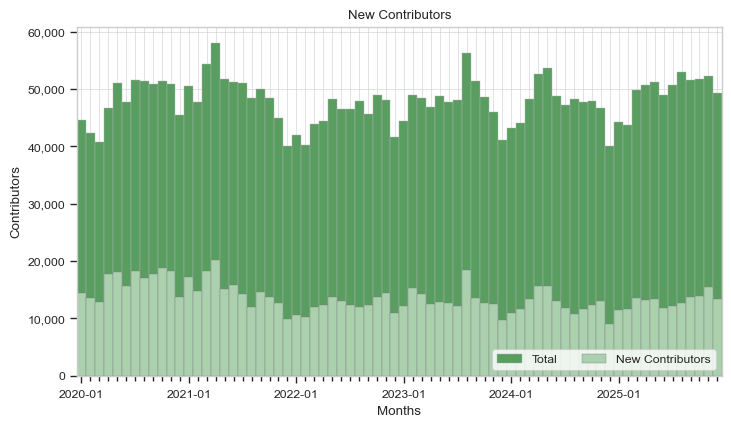

In [19]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper")

f = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 4, figure=f)

#ax0 = f.add_subplot(gs[0, 0:2])
#ax2 = f.add_subplot(gs[0, 2:4])
ax3 = f.add_subplot(gs[1, 1:3])   # centered under ax0/ax2

#f.suptitle("OpenStreetMap Contributions 2020–2026", fontsize=13, fontweight="bold", y=1.01)

def show_every_nth_ticklabel(ax, n=12, long_len=20, short_len=3.5, pad=5):
    for i, tick in enumerate(ax.xaxis.get_major_ticks()):
        show = (i % n == 0)
        tick.label1.set_visible(show)
        tick.tick1line.set_visible(True)
        tick.tick1line.set_markersize(long_len if show else short_len)
        if show:
            tick.set_pad(pad)


# Plot the New Contributors
ax3.set_title("New Contributors")
sns.barplot(x="Months", y="Contributors", data=df_20, ax=ax3, width=1,edgecolor="0.7", linewidth=0.3,
            label="Total", color="#4DAA57")

# Plot the crashes where alcohol was involved
sns.barplot(x="Months", y="New Contributors", data=df_20,ax=ax3,width=1, edgecolor="grey", linewidth=0.3,
            label="New Contributors", color="#a4d6a9")

# Add a legend and informative axis label
ax3.legend(ncol=2, loc="lower right", frameon=True, facecolor="w")
ax3.yaxis.set_major_formatter(plain_formatter)
ax3.grid(lw='0.4')


show_every_nth_ticklabel(ax3)


plt.tight_layout()
plt.show()

f.savefig("../results/NewContributors_20_25_v2.png", bbox_inches="tight", dpi=300)

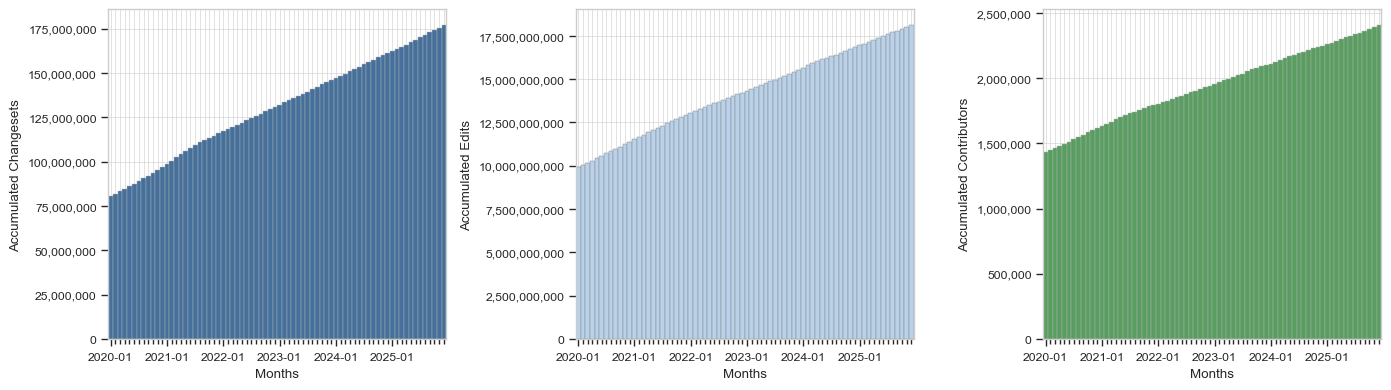

In [21]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))

def show_every_nth_ticklabel(ax, n=12, long_len=20, short_len=3.5, pad=5):
    for i, tick in enumerate(ax.xaxis.get_major_ticks()):
        show = (i % n == 0)
        tick.label1.set_visible(show)
        tick.tick1line.set_visible(True)
        tick.tick1line.set_markersize(long_len if show else short_len)
        if show:
            tick.set_pad(pad)

        

ax0 = ax[0]
sns.barplot(x="Months", y="Accumulated Changesets", data=df_20, width=1,edgecolor="0.7", linewidth=0.3,
            legend=False, color="#3670AB", ax=ax0)
ax0.yaxis.set_major_formatter(plain_formatter)
ax0.grid( lw='0.4')

ax2 = ax[1]
sns.barplot(x="Months", y="Accumulated Edits", data=df_20, width=1,edgecolor="grey", linewidth=0.3,
            legend=False, color="#B1D2F1", ax=ax2)
ax2.yaxis.set_major_formatter(plain_formatter)
ax2.grid(lw='0.4')

ax3 = ax[2]
sns.barplot(x="Months", y="Accumulated Contributors", data=df_20, width=1,edgecolor="0.7", linewidth=0.3,
            legend=False, color="#4DAA57", ax=ax3)
ax3.yaxis.set_major_formatter(plain_formatter)
ax3.grid(lw='0.4')

show_every_nth_ticklabel(ax0)
show_every_nth_ticklabel(ax2)
show_every_nth_ticklabel(ax3)




plt.tight_layout()
plt.show()

fig.savefig("../results/Accumulated_Edits_CS_Contributors_20_25_appendix_v2.png", bbox_inches="tight", dpi=300)